# OVRO-LWA subband source metacatalog

Identify sources in OVRO-LWA **frequency-subband** FITS images with **PyBDSF**, then
fuse per-image catalogs into a **metacatalog** with one entry per unique sky position.

This is the same pipeline as `ovro_lwa_metacatalog.ipynb`, generalized from four
color products to **15 subbands labeled by frequency** (18–82 MHz). The lowest
frequency seeds sequential association (the role Full plays for RGB); the other
14 subbands are associated in frequency order.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` (LST hour + subband from filenames).
2. **Detect** sources per image (`iter_detect_sources`); write each `sources_*.parquet` as it finishes.
3. **LST merge** within each subband (`merge_lst_metacatalog`).
4. **Band merge** sequential 18→23→…→82 MHz (`build_global_metacatalog`).

Catalogs are written as **Parquet** under `OUTPUT_DIR` via `CatalogLayout`.
Set `REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.
Set `MIGRATE_LEGACY_CSV = True` once to convert old CSV/FITS catalog trees.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, migrate_output_dir
from lwa_catalog.create import (
    build_global_metacatalog,
    discover_fits_files,
    discovered_slots,
    iter_detect_sources,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_metacatalog,
    write_sources_catalog,
)

# --- user configuration ---------------------------------------------------
#FITS_ROOT = Path("/fast/claw")  # directory containing FITS images (searched recursively)
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827")
# Glob(s) relative to FITS_ROOT (rglob). Default: all .fits. Examples:
#   "??h_*MHz/*_I_deep_Taper_Robust-0.75*pbcorr*fits"
FITS_GLOB = "??h_*MHz/*_I_deep_Taper_Robust-0.75*pbcorr*fits"
OUTPUT_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")  # Parquet catalog tree

# Upsample images before PyBDSF (finer pixel grid; WCS CDELT/CRPIX updated in detect)
BDSF_UPSAMPLE_FACTOR = 2

# PyBDSF detection parameters (ncores=1; parallelize across images instead)
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=3.0,
    thresh_pix=4.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=1,
)

# Worker processes for iter_detect_sources (one PyBDSF run per image)
DETECT_N_JOBS = 10

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None

# When True, skip PyBDSF / LST merge if matching Parquet files already exist
REUSE_CACHED_CATALOGS = True

# One-time CSV/FITS → Parquet migration (no-op if only Parquet is present)
MIGRATE_LEGACY_CSV = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

if MIGRATE_LEGACY_CSV:
    migrated = migrate_output_dir(layout)
    print(f"Migrated {len(migrated)} legacy catalog file(s) under {OUTPUT_DIR}")


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / frequency subband from filenames
(`lwa_catalog.create.discover`). Band names are the 15 frequency labels in
`COLOR_BANDS` below (e.g. `55MHz`).


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)
# Frequency subbands, low → high. SEED_BAND plays the Full role in sequential association.
COLOR_BANDS = tuple(reversed((
    "18MHz",
    "23MHz",
    "27MHz",
    "32MHz",
    "36MHz",
    "41MHz",
    "46MHz",
    "50MHz",
    "55MHz",
    "59MHz",
    "64MHz",
    "69MHz",
    "73MHz",
    "78MHz",
    "82MHz",
)))
SEED_BAND = COLOR_BANDS[0]
ASSOC_BANDS = COLOR_BANDS[1:]
SUBBAND_FREQ_HZ = {b: float(b.removesuffix("MHz")) * 1e6 for b in COLOR_BANDS}
SUBBAND_ALPHA_PAIRS = tuple(
    (f"{a.removesuffix('MHz')}_{b.removesuffix('MHz')}", a, b)
    for a, b in zip(COLOR_BANDS, COLOR_BANDS[1:])
)


In [3]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = [
    m
    for m in discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
    if m.band in COLOR_BANDS
]
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = list(LST_HOURS_OVERRIDE) if LST_HOURS_OVERRIDE is not None else _discovered_lst_hours
fits_by_slot = discovered_slots(fits_files)
summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_files],
        "lst_hour": [m.lst_hour for m in fits_files],
        "band": [m.band for m in fits_files],
        "time_key": [m.time_key for m in fits_files],
    }
)
print(f"Found {len(fits_files)} FITS files under {FITS_ROOT} matching {list(_fits_patterns)}")
print(
    f"Subbands in use ({len(COLOR_BANDS)}): {', '.join(COLOR_BANDS)}"
)
print(f"  seed: {SEED_BAND}; associate: {', '.join(ASSOC_BANDS)}")
missing = [b for b in COLOR_BANDS if b not in {m.band for m in fits_files}]
if missing:
    print(f"  WARNING: no FITS for {', '.join(missing)}")
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 330 FITS files under /lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827 matching ['??h_*MHz/*_I_deep_Taper_Robust-0.75*pbcorr*fits']
Subbands in use (15): 82MHz, 78MHz, 73MHz, 69MHz, 64MHz, 59MHz, 55MHz, 50MHz, 46MHz, 41MHz, 36MHz, 32MHz, 27MHz, 23MHz, 18MHz
  seed: 82MHz; associate: 78MHz, 73MHz, 69MHz, 64MHz, 59MHz, 55MHz, 50MHz, 46MHz, 41MHz, 36MHz, 32MHz, 27MHz, 23MHz, 18MHz
LST hours from discovery (22): 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h
LST hours in use (all discovered): 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h


,path,lst_hour,band,time_key
0,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,18MHz,None
1,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,23MHz,None
2,27MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,27MHz,None
3,32MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,32MHz,None
4,36MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,36MHz,None
...,...,...,...,...
325,64MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,22h,64MHz,None
326,69MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,22h,69MHz,None
327,73MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,22h,73MHz,None
328,78MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,22h,78MHz,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
Images are upsampled by `BDSF_UPSAMPLE_FACTOR` (default 2×) before detection.
`GAUL_COLUMNS` and `BDSF_KW` are notebook-local; cache helpers wrap Parquet I/O.


In [4]:
GAUL_COLUMNS = [
    "RA",
    "DEC",
    "S_Code",
    "Total_flux",
    "E_Total_flux",
    "Peak_flux",
    "E_Peak_flux",
    "Maj",
    "Min",
    "PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
    "Resid_Isl_rms",
    "Resid_Isl_mean",
]


def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def all_lst_merged_cached() -> bool:
    """True when every color band has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, COLOR_BANDS)


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged per-band catalogs from OUTPUT_DIR."""
    return read_all_lst_merged(layout, COLOR_BANDS)


In [5]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}
todo = []

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    todo.append((key, meta))

if todo:
    for meta, catalog in iter_detect_sources(
        [item_meta for _, item_meta in todo],
        n_jobs=DETECT_N_JOBS,
        bdsf_kw=BDSF_KW,
        gaul_columns=GAUL_COLUMNS,
        upsample_factor=BDSF_UPSAMPLE_FACTOR,
    ):
        key = (meta.lst_hour, meta.band)
        per_image_catalogs[key] = catalog
        out_path = write_sources_catalog(catalog, layout, meta.lst_hour, meta.band)
        print(f"Detected {key}: {len(catalog)} sources -> {out_path.name}")


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmp5ij2of5i.gaul.fits'
Detected ('01h', '18MHz'): 2570 sources -> sources_01h_18MHz.parquet
--> Wrote FITS file '/tmp/tmpb86m0apg.gaul.fits'
Detected ('01h', '23MHz'): 4045 sources -> sources_01h_23MHz.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmpb8errjk4.gaul.fits'
Detected ('01h', '27MHz'): 5972 sources -> sources_01h_27MHz.parquet
--> Wrote FITS file '/tmp/tmpklhk0ihj.gaul.fits'


stty: 'standard input': Inappropriate ioctl for device


...

--> Wrote FITS file '/tmp/tmpj62acbh1.gaul.fits'
Detected ('22h', '64MHz'): 20272 sources -> sources_22h_64MHz.parquet


stty: 'standard input': Inappropriate ioctl for device
/opt/devel/claw/envs/py312/lib/python3.12/site-packages/bdsf/functions.py:624: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, success = leastsq(errorfunction, p_ini)
stty: 'standard input': Inappropriate ioctl for device
/opt/devel/claw/envs/py312/lib/python3.12/site-packages/bdsf/functions.py:624: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, success = leastsq(errorfunction, p_ini)


--> Wrote FITS file '/tmp/tmp8ezzvfzv.gaul.fits'
Detected ('22h', '78MHz'): 24856 sources -> sources_22h_78MHz.parquet
--> Wrote FITS file '/tmp/tmplgr2lw3w.gaul.fits'
Detected ('22h', '73MHz'): 23416 sources -> sources_22h_73MHz.parquet
--> Wrote FITS file '/tmp/tmp2t2z_x5g.gaul.fits'
Detected ('22h', '82MHz'): 18783 sources -> sources_22h_82MHz.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmpzble_kib.gaul.fits'
Detected ('22h', '69MHz'): 21465 sources -> sources_22h_69MHz.parquet
--> Wrote FITS file '/tmp/tmpndh8cf1_.gaul.fits'
Detected ('22h', '41MHz'): 8777 sources -> sources_22h_41MHz.parquet


## Metacatalog fusion

LST merge within each frequency subband, then sequential association
18→23→…→82 MHz (`lwa_catalog.create.merge`). `SEED_BAND` seeds rows (like Full);
`ASSOC_BANDS` are attached in order. Adjacent-channel spectral indices use
`SUBBAND_FREQ_HZ` and `SUBBAND_ALPHA_PAIRS`. `BAND_FIELDS` includes `E_Total_flux`
for `E_alpha_*`.


In [6]:
from lwa_catalog.constants import BAND_FIELDS

# BAND_FIELDS must include E_Total_flux so associated errors propagate into
# E_Total_flux_{band} and then E_alpha_* for adjacent subband pairs.
assert "E_Total_flux" in BAND_FIELDS


In [7]:
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in COLOR_BANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in COLOR_BANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

metacatalog = build_global_metacatalog(
    lst_merged,
    seed_band=SEED_BAND,
    assoc_bands=ASSOC_BANDS,
    band_fields=BAND_FIELDS,
    color_bands=COLOR_BANDS,
    band_freq_hz=SUBBAND_FREQ_HZ,
    spectral_index_pairs=SUBBAND_ALPHA_PAIRS,
)
meta_path = write_metacatalog(metacatalog, layout)

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = sum(int(df["n_lst_contributions"].sum()) for df in lst_merged.values())
    input_desc = f"{n_inputs} LST-merged rows (cached)"
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {input_desc}")
print(f"Wrote {meta_path}")
metacatalog.head(10)


LST merge (82MHz): 94909 sources -> /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_lst_82MHz.parquet
LST merge (78MHz): 104027 sources -> /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_lst_78MHz.parquet
LST merge (73MHz): 96269 sources -> /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_lst_73MHz.parquet
LST merge (69MHz): 90034 sources -> /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_lst_69MHz.parquet
LST merge (64MHz): 85207 sources -> /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_lst_64MHz.parquet
LST merge (59MHz): 71688 sources -> /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_lst_59MHz.parquet
LST merge (55MHz): 65419 sources -> /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_lst_55MHz.parquet
LST merge (50MHz): 57860 sources -> /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_lst_50MHz.parquet
LST merge (46MHz): 49641 sources -> /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_lst_46MHz.parquet
LST merge (41MHz):

,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,alpha_41_36,E_alpha_41_36,alpha_36_32,E_alpha_36_32,alpha_32_27,E_alpha_32_27,alpha_27_23,E_alpha_27_23,alpha_23_18,E_alpha_23_18
0,94909,78MHz,"78MHz,73MHz,64MHz,59MHz,55MHz,50MHz,46MHz,41MH...",252.802964,5.005611,305.349240,290.668212,0.127061,0.076937,178.687471,...,2.932739,0.077207,9.485061,0.947448,2.392897,0.676696,-19.990045,0.187020,2.790577,0.128417
1,0,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,46MH...",139.494476,-12.088876,251.482415,201.821141,0.159108,0.060091,2.982513,...,-5.609536,0.048714,6.158361,0.085032,5.519403,0.163237,-13.534250,0.166892,23.397410,0.587686
2,163621,23MHz,23MHz,287.544123,-0.689233,190.936463,1192.254084,3.558936,0.906451,11.115068,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,163622,23MHz,23MHz,267.573046,-26.499173,183.054315,1804.595696,3.936227,1.069288,10.455737,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,162937,36MHz,"36MHz,32MHz,27MHz,23MHz,18MHz",284.097108,1.414375,171.352276,363.730390,0.401279,0.253057,154.202248,...,NaN,NaN,-1.941955,0.293138,0.990832,0.265870,-5.358401,0.295051,0.295905,0.226005
5,163623,23MHz,23MHz,264.818714,-30.011090,156.316864,156.316864,0.828995,0.498862,159.567107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,82MHz,"82MHz,78MHz,73MHz,50MHz,46MHz,41MHz,36MHz,32MH...",69.215486,29.677279,142.901985,114.658749,0.088427,0.069828,5.307086,...,5.238310,0.114460,14.413277,0.324435,NaN,NaN,NaN,NaN,-4.105654,0.095621
7,94910,78MHz,"78MHz,59MHz,32MHz,27MHz,23MHz,18MHz",139.727468,-11.925412,135.478419,22.324539,0.255563,0.044778,14.313817,...,NaN,NaN,NaN,NaN,-14.729519,0.499508,-13.534250,0.166892,23.397410,0.587686
8,157926,55MHz,"55MHz,50MHz,46MHz",267.244114,-27.675161,132.340050,3115.216628,3.003560,0.504799,45.561089,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,163705,18MHz,18MHz,263.322919,-28.440480,124.283391,1299.859018,5.776449,1.002223,26.348209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# LST merge yield (seed subband)
seed_lst = lst_merged[SEED_BAND]
multi_lst = seed_lst[seed_lst["n_lst_contributions"] > 1].sort_values(
    "n_lst_contributions", ascending=False
)
print(f"{SEED_BAND} sources after LST merge: {len(seed_lst)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(
        multi_lst.head(10)[
            ["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]
        ]
    )

# Global band merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

assoc_cols = [f"n_assoc_{b}" for b in ASSOC_BANDS if f"n_assoc_{b}" in metacatalog.columns]
seed_with_assoc = metacatalog[
    (metacatalog["origin_band"] == SEED_BAND)
    & (metacatalog[assoc_cols].max(axis=1) > 0)
]
print(
    f"{SEED_BAND}-seeded rows with at least one other-subband association: "
    f"{len(seed_with_assoc)}"
)
show_cols = [
    c
    for c in ["meta_id", "RA", "DEC", "origin_band", "Peak_flux", "lst_hours", "bands_present"]
    if c in metacatalog.columns
]
metacatalog.head(10)[show_cols]


82MHz sources after LST merge: 94909
  seen in multiple LST hours: 63558


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
18064,352.329622,59.131851,2.117202,540,"01h,02h,03h,04h,05h,06h,07h,08h,14h,15h,16h,17...",22h
17911,301.004189,40.839200,2.125660,490,"01h,02h,13h,14h,15h,16h,17h,18h,19h,20h,21h,22h",20h
4901,84.560904,21.696931,3.977797,316,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h",06h
13047,188.316876,12.000833,2.470002,302,"07h,08h,09h,10h,11h,12h,13h,14h,15h,16h,17h",13h
136,7.376262,63.986680,18.263921,269,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",01h
718,304.939138,40.092470,9.645690,264,"01h,02h,03h,13h,14h,15h,16h,17h,18h,19h,20h,21...",20h
1819,253.024764,5.266728,6.444321,255,"12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",17h
1,69.215486,29.677279,142.901985,246,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,22h",05h
124,260.155179,-0.994788,18.754285,218,"12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",17h
9,212.862994,52.214140,58.036782,181,"06h,07h,08h,09h,10h,11h,12h,13h,14h,15h,16h,17...",14h



Global rows by origin_band:
origin_band
82MHz    94909
78MHz    30045
73MHz    13896
69MHz     9025
64MHz     6735
59MHz     3316
55MHz     2004
50MHz     1411
46MHz      878
41MHz      718
36MHz      302
32MHz      214
27MHz      168
23MHz       84
18MHz       80
Name: count, dtype: int64
82MHz-seeded rows with at least one other-subband association: 86245


,meta_id,RA,DEC,origin_band,Peak_flux,lst_hours,bands_present
0,94909,252.802964,5.005611,78MHz,305.349240,"12h,13h,14h,15h,16h,17h,18h,19h,20h,21h","78MHz,73MHz,64MHz,59MHz,55MHz,50MHz,46MHz,41MH..."
1,0,139.494476,-12.088876,82MHz,251.482415,"05h,06h,07h,08h,09h,10h,11h,12h,13h","82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,46MH..."
2,163621,287.544123,-0.689233,23MHz,190.936463,14h,23MHz
3,163622,267.573046,-26.499173,23MHz,183.054315,20h,23MHz
4,162937,284.097108,1.414375,36MHz,171.352276,"14h,15h,16h,17h,18h,19h,20h,21h,22h","36MHz,32MHz,27MHz,23MHz,18MHz"
5,163623,264.818714,-30.011090,23MHz,156.316864,"15h,16h,19h",23MHz
6,1,69.215486,29.677279,82MHz,142.901985,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,22h","82MHz,78MHz,73MHz,50MHz,46MHz,41MHz,36MHz,32MH..."
7,94910,139.727468,-11.925412,78MHz,135.478419,13h,"78MHz,59MHz,32MHz,27MHz,23MHz,18MHz"
8,157926,267.244114,-27.675161,55MHz,132.340050,"15h,16h","55MHz,50MHz,46MHz"
9,163705,263.322919,-28.440480,18MHz,124.283391,15h,18MHz


## Fit quality

Summarize detection fit quality on **`lst_merged`** (representative-row residuals and fluxes).
Requires the fusion cells above so `lst_merged` is populated.

Three categories:

1. **Island residual stats** — flag the top 1% of `Resid_Isl_rms` and the top 1% of
   `|Resid_Isl_mean|` within each band (union = high-residual set).
2. **Unphysical flux ratio** — allow `Total_flux < Peak_flux` within error; flag only when
   `(Total_flux - Peak_flux) / hypot(E_Total_flux, E_Peak_flux) < -3`.
   Rows missing either error are not flagged.
3. **Source density** — 1°×1° RA–Dec histogram; report densest bins and overlay flagged
   sources on the seed-subband map. Flat RA–Dec bins exaggerate area near the NCP.

This section is read-only QA (does not rewrite Parquet catalogs).


In [ ]:
import numpy as np

FLUX_UNPHYSICAL_NSIGMA = 3.0
RESIDUAL_PERCENTILE = 99.0  # top 1%
DENSITY_BIN_DEG = 3.0
FIT_QA_DISPLAY_ROWS = 15

_RESID_COLS = ("Resid_Isl_rms", "Resid_Isl_mean")
_FLUX_COLS = ("Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux")
_POS_COLS = ("RA", "DEC")


def _missing_columns(df: pd.DataFrame, cols: tuple[str, ...]) -> list[str]:
    return [c for c in cols if c not in df.columns]


def flux_sigma_total_minus_peak(df: pd.DataFrame) -> pd.Series:
    """Return (Total - Peak) / hypot(E_Total, E_Peak); non-finite where inputs invalid."""
    missing = _missing_columns(df, _FLUX_COLS)
    if missing:
        return pd.Series(np.nan, index=df.index, dtype=float)
    total = df["Total_flux"].to_numpy(dtype=float)
    peak = df["Peak_flux"].to_numpy(dtype=float)
    e_tot = df["E_Total_flux"].to_numpy(dtype=float)
    e_peak = df["E_Peak_flux"].to_numpy(dtype=float)
    denom = np.hypot(e_tot, e_peak)
    sigma = np.full(len(df), np.nan, dtype=float)
    ok = (
        np.isfinite(total)
        & np.isfinite(peak)
        & np.isfinite(e_tot)
        & np.isfinite(e_peak)
        & (denom > 0)
    )
    sigma[ok] = (total[ok] - peak[ok]) / denom[ok]
    return pd.Series(sigma, index=df.index, name="flux_sigma_T_minus_P")


def flag_unphysical_flux(
    df: pd.DataFrame, *, nsigma: float = FLUX_UNPHYSICAL_NSIGMA
) -> pd.Series:
    """True where Total is significantly below Peak (sigma < -nsigma). Missing errors → False."""
    sigma = flux_sigma_total_minus_peak(df)
    return (sigma < -float(nsigma)).fillna(False).rename("unphysical_flux")


def flag_residual_top_percentile(
    df: pd.DataFrame, *, percentile: float = RESIDUAL_PERCENTILE
) -> pd.DataFrame:
    """Boolean columns: high_resid_rms, high_resid_abs_mean, high_residual (union)."""
    out = pd.DataFrame(index=df.index)
    missing = _missing_columns(df, _RESID_COLS)
    if missing:
        out["high_resid_rms"] = False
        out["high_resid_abs_mean"] = False
        out["high_residual"] = False
        return out

    rms = df["Resid_Isl_rms"].to_numpy(dtype=float)
    mean = df["Resid_Isl_mean"].to_numpy(dtype=float)
    abs_mean = np.abs(mean)

    high_rms = np.zeros(len(df), dtype=bool)
    high_abs = np.zeros(len(df), dtype=bool)

    finite_rms = np.isfinite(rms)
    if finite_rms.any():
        thr_rms = np.nanpercentile(rms[finite_rms], percentile)
        high_rms = finite_rms & (rms >= thr_rms)

    finite_abs = np.isfinite(abs_mean)
    if finite_abs.any():
        thr_abs = np.nanpercentile(abs_mean[finite_abs], percentile)
        high_abs = finite_abs & (abs_mean >= thr_abs)

    out["high_resid_rms"] = high_rms
    out["high_resid_abs_mean"] = high_abs
    out["high_residual"] = high_rms | high_abs
    return out


def sky_density_histogram(
    df: pd.DataFrame, *, bin_deg: float = DENSITY_BIN_DEG
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (H, ra_edges, dec_edges) for finite RA/DEC with fixed bin width in degrees."""
    missing = _missing_columns(df, _POS_COLS)
    if missing:
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = df["RA"].to_numpy(dtype=float)
    dec = df["DEC"].to_numpy(dtype=float)
    ok = np.isfinite(ra) & np.isfinite(dec)
    if not ok.any():
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = ra[ok]
    dec = dec[ok]
    bin_deg = float(bin_deg)
    ra_min, ra_max = np.floor(ra.min() / bin_deg) * bin_deg, np.ceil(ra.max() / bin_deg) * bin_deg
    dec_min, dec_max = np.floor(dec.min() / bin_deg) * bin_deg, np.ceil(dec.max() / bin_deg) * bin_deg
    if ra_max <= ra_min:
        ra_max = ra_min + bin_deg
    if dec_max <= dec_min:
        dec_max = dec_min + bin_deg
    n_ra = max(1, int(np.round((ra_max - ra_min) / bin_deg)))
    n_dec = max(1, int(np.round((dec_max - dec_min) / bin_deg)))
    ra_edges = ra_min + np.arange(n_ra + 1) * bin_deg
    dec_edges = dec_min + np.arange(n_dec + 1) * bin_deg
    H, _, _ = np.histogram2d(ra, dec, bins=[ra_edges, dec_edges])
    return H, ra_edges, dec_edges


def densest_bins(
    H: np.ndarray,
    ra_edges: np.ndarray,
    dec_edges: np.ndarray,
    *,
    n: int = 10,
) -> pd.DataFrame:
    """Return the densest histogram bins (count, bin centers)."""
    if H.size == 0:
        return pd.DataFrame(columns=["count", "RA_center", "DEC_center", "i_ra", "i_dec"])
    flat = H.ravel()
    order = np.argsort(flat)[::-1]
    rows = []
    for idx in order[: max(0, int(n))]:
        if flat[idx] <= 0:
            break
        i_ra, i_dec = np.unravel_index(int(idx), H.shape)
        rows.append(
            {
                "count": int(flat[idx]),
                "RA_center": float(0.5 * (ra_edges[i_ra] + ra_edges[i_ra + 1])),
                "DEC_center": float(0.5 * (dec_edges[i_dec] + dec_edges[i_dec + 1])),
                "i_ra": int(i_ra),
                "i_dec": int(i_dec),
            }
        )
    return pd.DataFrame(rows)


print(
    f"Fit-quality helpers ready "
    f"(residual p{RESIDUAL_PERCENTILE:g}, unphysical {FLUX_UNPHYSICAL_NSIGMA:g}σ, "
    f"density {DENSITY_BIN_DEG:g}°)."
)


Fit-quality helpers ready (residual p99, unphysical 3σ, density 3°).


In [ ]:
# Per-band residual + unphysical flux summaries (stores fit_qa for density overlay)
fit_qa: dict[str, dict] = {}

for band in COLOR_BANDS:
    df = lst_merged[band]
    print(f"\n=== {band}: {len(df)} LST-merged sources ===")
    entry: dict = {
        "n_sources": int(len(df)),
        "high_residual": pd.Series(False, index=df.index),
        "unphysical_flux": pd.Series(False, index=df.index),
        "flux_sigma": pd.Series(np.nan, index=df.index),
        "skipped_residual": False,
        "skipped_flux": False,
    }

    miss_resid = _missing_columns(df, _RESID_COLS)
    if miss_resid:
        print(f"  SKIP residual QA — missing columns: {miss_resid}")
        entry["skipped_residual"] = True
        entry["n_resid_top1"] = 0
    else:
        flags = flag_residual_top_percentile(df, percentile=RESIDUAL_PERCENTILE)
        entry["high_residual"] = flags["high_residual"]
        entry["n_resid_top1"] = int(flags["high_residual"].sum())
        n_rms = int(flags["high_resid_rms"].sum())
        n_abs = int(flags["high_resid_abs_mean"].sum())
        n_finite_rms = int(np.isfinite(df["Resid_Isl_rms"].to_numpy(dtype=float)).sum())
        print(
            f"  Residual top-1%: union={entry['n_resid_top1']} "
            f"(rms={n_rms}, |mean|={n_abs}; finite Resid_Isl_rms={n_finite_rms})"
        )
        show_cols = [c for c in ["RA", "DEC", "Peak_flux", "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"] if c in df.columns]
        outliers = (
            df.loc[flags["high_residual"], show_cols]
            .assign(_sort=df.loc[flags["high_residual"], "Resid_Isl_rms"])
            .sort_values("_sort", ascending=False)
            .drop(columns="_sort")
            .head(FIT_QA_DISPLAY_ROWS)
        )
        if len(outliers):
            display(outliers)
        else:
            print("  (no residual outliers)")

    miss_flux = _missing_columns(df, _FLUX_COLS)
    if miss_flux:
        print(f"  SKIP unphysical-flux QA — missing columns: {miss_flux}")
        entry["skipped_flux"] = True
        entry["n_unphysical_3sig"] = 0
    else:
        sigma = flux_sigma_total_minus_peak(df)
        unphys = flag_unphysical_flux(df, nsigma=FLUX_UNPHYSICAL_NSIGMA)
        entry["flux_sigma"] = sigma
        entry["unphysical_flux"] = unphys
        entry["n_unphysical_3sig"] = int(unphys.sum())
        print(f"  Unphysical flux (σ < -{FLUX_UNPHYSICAL_NSIGMA:g}): {entry['n_unphysical_3sig']}")
        show_cols = [c for c in ["RA", "DEC", "Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux"] if c in df.columns]
        bad = df.loc[unphys, show_cols].copy()
        bad.insert(0, "flux_sigma_T_minus_P", sigma.loc[unphys])
        bad = bad.sort_values("flux_sigma_T_minus_P").head(FIT_QA_DISPLAY_ROWS)
        if len(bad):
            display(bad)
        else:
            print("  (no unphysical-flux sources)")

    fit_qa[band] = entry

print("\nStored per-band flags in fit_qa.")



=== 82MHz: 94909 LST-merged sources ===
  Residual top-1%: union=1463 (rms=950, |mean|=950; finite Resid_Isl_rms=94909)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
2256,187.573665,11.509621,5.808885,25.833981,-7.824338,b'M'
22845,5.782171,64.477504,1.894501,9.983803,-8.954540,b'M'
237,201.210369,-42.252038,14.815309,9.412956,2.593130,b'M'
5697,201.022078,-40.900995,3.694810,9.412956,2.593130,b'M'
464,202.125550,-41.536053,11.402864,9.412956,2.593130,b'C'
30,201.710065,-42.564221,34.252483,9.412956,2.593130,b'M'
3066,200.775921,-42.225381,4.971973,9.412956,2.593130,b'C'
4173,201.710763,-41.399668,4.290590,9.412956,2.593130,b'M'
3788,202.845229,-41.389570,4.483589,9.412956,2.593130,b'C'
164,201.308829,-41.551978,17.139497,9.412956,2.593130,b'M'


  Unphysical flux (σ < -3): 265


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
27283,-5395.842210,60.825072,43.013750,0.000250,1.740934,0.000222,0.000234
71842,-458.365348,114.450211,47.618822,0.000137,0.778429,0.001691,0.000153
75,-296.128105,24.093922,20.898063,3.064948,22.134572,0.058524,0.026868
244,-290.193346,134.521950,27.803194,1.683214,14.712279,0.041122,0.018022
232,-179.591039,319.601177,49.613604,1.699444,14.942375,0.065121,0.034593
12,-150.506501,49.932234,41.495553,33.096931,56.260615,0.128663,0.084455
532,-140.173978,47.489619,17.108935,1.714079,10.793125,0.058385,0.028042
263,-134.352022,44.413938,6.002163,2.352921,14.301866,0.082511,0.033193
387,-115.317422,63.077437,-1.050135,1.664747,12.102737,0.083127,0.035818
134,-113.626600,116.725412,-19.391260,1.854626,18.385870,0.118794,0.083992



=== 78MHz: 104027 LST-merged sources ===
  Residual top-1%: union=1549 (rms=1041, |mean|=1041; finite Resid_Isl_rms=104027)


...


=== 18MHz: 8463 LST-merged sources ===
  Residual top-1%: union=107 (rms=87, |mean|=85; finite Resid_Isl_rms=8463)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
176,49.910783,-36.320938,92.077165,158.949951,-113.843521,b'M'
367,348.348324,60.069936,62.370091,155.244263,66.580070,b'M'
127,348.052045,61.789830,110.222996,140.531754,52.992611,b'M'
199,354.033621,61.386292,85.419197,140.531754,52.992611,b'C'
114,347.533862,59.997692,114.304973,140.531754,52.992611,b'M'
10,349.308044,60.619470,305.582663,140.531754,52.992611,b'M'
554,250.529977,4.263925,50.468356,76.816078,-9.836905,b'C'
3488,254.319705,5.926488,20.820489,76.816078,-9.836905,b'M'
712,251.535046,4.536159,44.774386,76.816078,-9.836905,b'C'
133,140.327820,-11.032623,108.617852,70.800819,54.394772,b'M'


  Unphysical flux (σ < -3): 31


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
10,-206.989930,349.308044,60.619470,30.358237,305.582663,0.779942,1.076876
133,-185.517898,140.327820,-11.032623,5.576626,108.617852,0.181062,0.525084
1993,-43.415985,333.619563,-16.822139,1.891117,27.201409,0.215480,0.541687
755,-39.688093,139.540711,-11.866500,3.360064,43.251214,0.483661,0.881096
215,-24.948832,345.094357,62.487008,14.540703,82.064250,2.038741,1.780050
274,-24.606537,355.693391,55.425832,11.311486,72.368047,1.395190,2.051918
775,-22.987445,348.791731,64.005840,4.992997,42.814960,1.157410,1.169409
2,-20.748402,69.192654,29.760295,413.083869,539.264411,5.028021,3.420985
76,-19.008671,299.687617,40.692235,46.426434,136.205887,3.463251,3.211443
127,-18.296354,348.052045,61.789830,37.541897,110.222996,2.900262,2.714541



Stored per-band flags in fit_qa.


Densest 3° bins (82MHz):


,count,RA_center,DEC_center,i_ra,i_dec
0,156,187.5,10.5,62,18
1,155,187.5,13.5,62,19
2,144,253.5,4.5,84,16
3,125,82.5,22.5,27,22
4,125,139.5,-13.5,46,10
5,115,139.5,-10.5,46,11
6,111,298.5,40.5,99,28
7,110,301.5,40.5,100,28
8,105,187.5,1.5,62,15
9,96,187.5,7.5,62,17


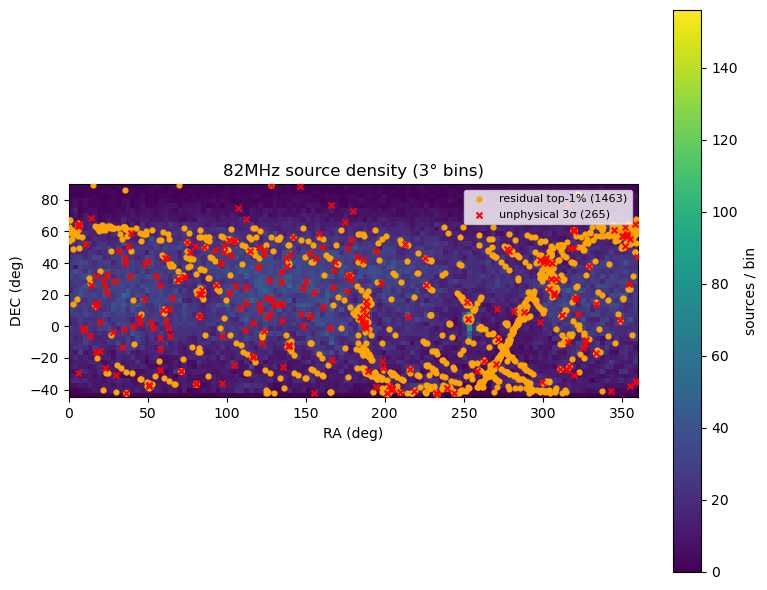


Fit-quality roll-up:


,band,n_sources,n_resid_top1,n_unphysical_3sig,max_bin_count,n_resid_and_unphysical
0,82MHz,94909,1463,265,156,73
1,78MHz,104027,1549,322,147,86
2,73MHz,96269,1412,287,133,75
3,69MHz,90034,1313,214,113,42
4,64MHz,85207,1245,176,103,43
5,59MHz,71688,1011,179,87,43
6,55MHz,65419,902,150,68,44
7,50MHz,57860,782,97,58,27
8,46MHz,49641,659,68,48,20
9,41MHz,41990,578,57,39,22


In [ ]:
import matplotlib.pyplot as plt

# Seed-subband density map + flagged overlays; roll-up for all subbands
primary_band = SEED_BAND if SEED_BAND in lst_merged else COLOR_BANDS[0]
df_full = lst_merged[primary_band]
H, ra_edges, dec_edges = sky_density_histogram(df_full, bin_deg=DENSITY_BIN_DEG)
top_bins = densest_bins(H, ra_edges, dec_edges, n=10)
print(f"Densest {DENSITY_BIN_DEG:g}° bins ({primary_band}):")
display(top_bins)

if H.size:
    fig, ax = plt.subplots(figsize=(8, 6))
    # H is (n_ra, n_dec); pcolormesh expects X,Y as edges
    mesh = ax.pcolormesh(ra_edges, dec_edges, H.T, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label="sources / bin")
    qa = fit_qa.get(primary_band, {})
    high = qa.get("high_residual", pd.Series(False, index=df_full.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df_full.index))
    if high.any():
        ax.scatter(
            df_full.loc[high, "RA"],
            df_full.loc[high, "DEC"],
            s=12,
            c="orange",
            marker="o",
            label=f"residual top-1% ({int(high.sum())})",
            zorder=3,
        )
    if unphys.any():
        ax.scatter(
            df_full.loc[unphys, "RA"],
            df_full.loc[unphys, "DEC"],
            s=18,
            c="red",
            marker="x",
            label=f"unphysical 3σ ({int(unphys.sum())})",
            zorder=4,
        )
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("DEC (deg)")
    ax.set_title(f"{primary_band} source density ({DENSITY_BIN_DEG:g}° bins)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print(f"No finite RA/DEC for density map ({primary_band}).")

# Roll-up summary across bands
rows = []
for band in COLOR_BANDS:
    df = lst_merged[band]
    qa = fit_qa.get(band, {})
    H_b, _, _ = sky_density_histogram(df, bin_deg=DENSITY_BIN_DEG)
    max_bin = int(H_b.max()) if H_b.size else 0
    high = qa.get("high_residual", pd.Series(False, index=df.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df.index))
    rows.append(
        {
            "band": band,
            "n_sources": int(len(df)),
            "n_resid_top1": int(qa.get("n_resid_top1", high.sum())),
            "n_unphysical_3sig": int(qa.get("n_unphysical_3sig", unphys.sum())),
            "max_bin_count": max_bin,
            "n_resid_and_unphysical": int((high & unphys).sum()),
        }
    )

fit_qa_summary = pd.DataFrame(rows)
print("\nFit-quality roll-up:")
display(fit_qa_summary)


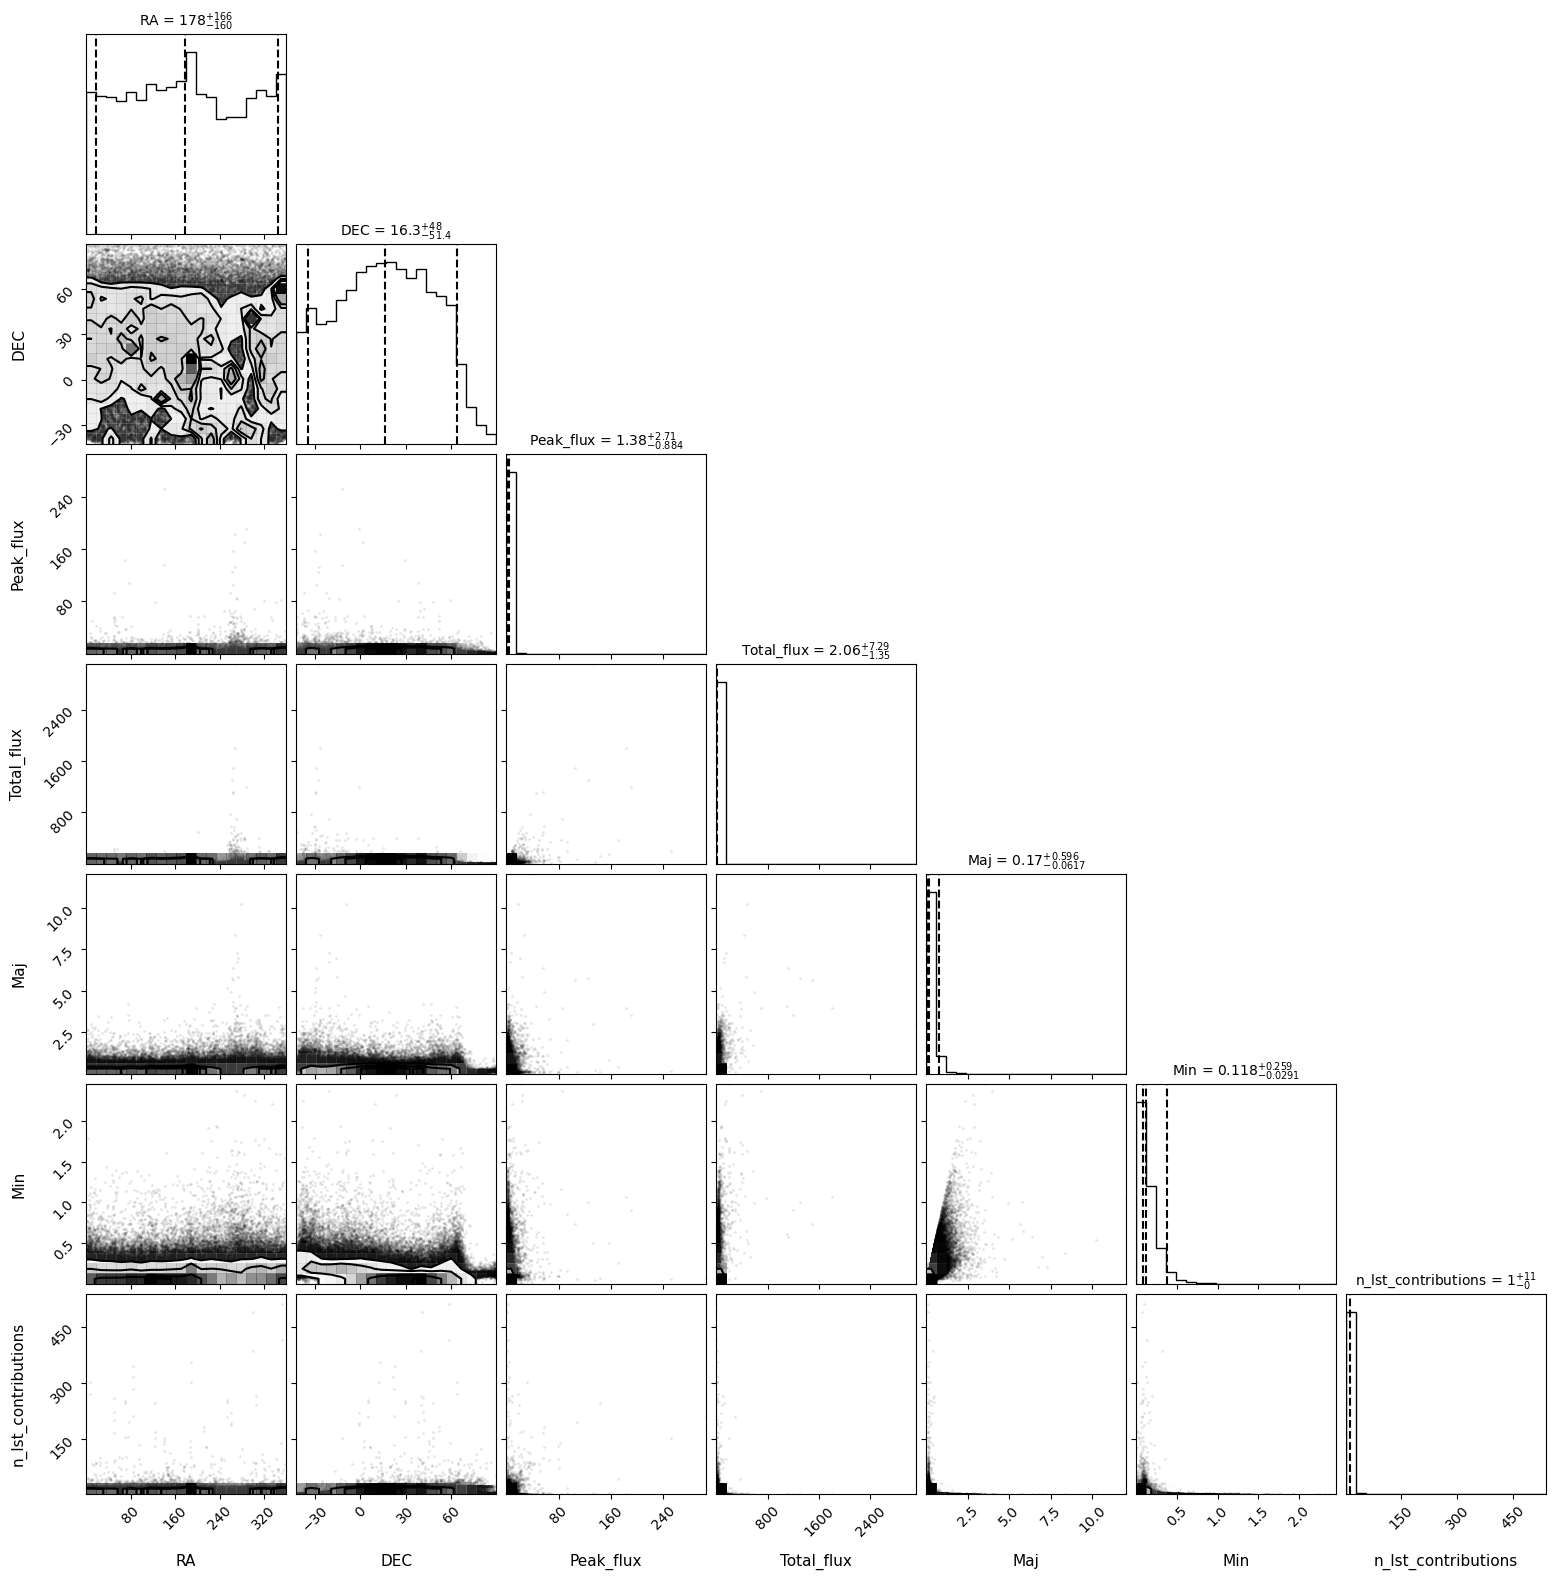

In [ ]:
import corner
import matplotlib.pyplot as plt

cols = ["RA", "DEC", "Peak_flux", "Total_flux", "Maj", "Min", "n_lst_contributions"]

# drop NaNs; corner needs a clean numeric array
data = metacatalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

# Save before show — Cursor/VS Code often cannot "download" inline plot images.
#OUT_PNG = OUTPUT_DIR / "metacatalog_corner.png"
#fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
#print(f"Wrote {OUT_PNG}")
plt.show()


## Spectral index distribution

Adjacent-channel α for each consecutive subband pair
(`α = log(S_a/S_b) / log(ν_a/ν_b)`). The scatter uses the two pairs nearest
mid-band (analogous to α_RG vs α_GB in the color metacatalog).


Finite adjacent-channel spectral indices:


,pair,n_finite
0,82_78,74112
1,78_73,79757
2,73_69,76262
3,69_64,73547
4,64_59,66888
5,59_55,63015
6,55_50,59257
7,50_46,54570
8,46_41,49974
9,41_36,41893


Scatter: alpha_55_50 vs alpha_50_46 (50262 sources with both)


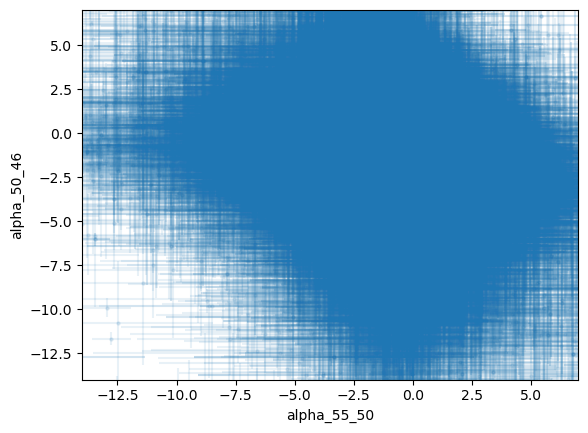

In [ ]:
pair_labels = [lab for lab, _, _ in SUBBAND_ALPHA_PAIRS]
alpha_n = pd.DataFrame(
    {
        "pair": pair_labels,
        "n_finite": [
            int(metacatalog[f"alpha_{lab}"].notna().sum())
            if f"alpha_{lab}" in metacatalog.columns
            else 0
            for lab in pair_labels
        ],
    }
)
print("Finite adjacent-channel spectral indices:")
display(alpha_n)

mid = len(pair_labels) // 2
lab_lo, lab_hi = pair_labels[max(0, mid - 1)], pair_labels[min(len(pair_labels) - 1, mid)]
cols = [
    "meta_id",
    f"alpha_{lab_lo}",
    f"E_alpha_{lab_lo}",
    f"alpha_{lab_hi}",
    f"E_alpha_{lab_hi}",
]
data = metacatalog[cols].dropna(how="any")
print(f"Scatter: alpha_{lab_lo} vs alpha_{lab_hi} ({len(data)} sources with both)")
ax = data.plot(
    x=f"alpha_{lab_lo}",
    y=f"alpha_{lab_hi}",
    xerr=f"E_alpha_{lab_lo}",
    yerr=f"E_alpha_{lab_hi}",
    marker=".",
    kind="scatter",
    alpha=0.1,
    xlim=[-14, 7],
    ylim=[-14, 7],
)
OUT_PNG = OUTPUT_DIR / "metacatalog_subband_alpha.png"
ax.figure.savefig(OUT_PNG, dpi=150, bbox_inches="tight")


In [ ]:
meta_ids = data[(data[f"alpha_{lab_lo}"] > 1) & (data[f"alpha_{lab_hi}"] < -2)]["meta_id"]


In [ ]:
metacatalog.set_index('meta_id').loc[meta_ids].reset_index()

,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,alpha_41_36,E_alpha_41_36,alpha_36_32,E_alpha_36_32,alpha_32_27,E_alpha_32_27,alpha_27_23,E_alpha_27_23,alpha_23_18,E_alpha_23_18
0,94909,78MHz,"78MHz,73MHz,64MHz,59MHz,55MHz,50MHz,46MHz,41MH...",252.802964,5.005611,305.349240,290.668212,0.127061,0.076937,178.687471,...,2.932739,0.077207,9.485061,0.947448,2.392897,0.676696,-19.990045,0.187020,2.790577,0.128417
1,157926,55MHz,"55MHz,50MHz,46MHz",267.244114,-27.675161,132.340050,3115.216628,3.003560,0.504799,45.561089,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,154610,59MHz,"59MHz,55MHz,50MHz,46MHz,41MHz,36MHz,32MHz,27MH...",123.318758,48.218816,79.433829,59.320163,0.109914,0.094213,2.436741,...,-3.373926,0.285466,12.181906,0.882975,-21.391022,0.601060,1.253289,0.094589,-1.469307,0.085472
3,31,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,50MH...",184.856447,5.854923,33.884854,47.076700,0.129336,0.102869,116.542359,...,1.013815,0.153056,-2.348194,0.188038,NaN,NaN,NaN,NaN,-0.196396,0.148852
4,138851,69MHz,"69MHz,64MHz,59MHz,55MHz,50MHz,46MHz,41MHz,36MH...",59.671818,10.437201,33.483797,18.076764,0.122255,0.052819,0.146754,...,-14.420031,0.197031,39.053710,1.838533,-28.422810,1.275229,-0.931427,0.102017,-0.917785,0.086151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2293,138817,73MHz,"73MHz,69MHz,64MHz,59MHz,55MHz,50MHz,46MHz,36MH...",151.651312,44.574039,0.364193,0.718134,0.153386,0.121121,133.481332,...,NaN,NaN,-1.057796,0.501803,-0.635814,0.429469,-0.856622,0.584797,-0.639896,0.526239
2294,124846,78MHz,"78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,50MHz,46MH...",154.068180,41.919454,0.341007,0.596604,0.147017,0.099308,50.842446,...,NaN,NaN,NaN,NaN,-1.271188,2.021674,-1.256061,2.602971,NaN,NaN
2295,124876,78MHz,"78MHz,55MHz,50MHz,46MHz,41MHz,36MHz,32MHz",201.708726,45.974235,0.332499,0.517582,0.140822,0.100813,57.800073,...,-2.168200,2.998322,-0.547578,3.951567,NaN,NaN,NaN,NaN,NaN,NaN
2296,124879,78MHz,"78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,50MHz,46MH...",153.984856,42.018102,0.331249,0.536613,0.128464,0.105255,170.698476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.042131,1.822632
